## orflib Library Examples

In [1]:
import orflib as orf
import numpy as np
import os
import matplotlib.pyplot as plt
plt.style.use('ggplot')

print("orflib version: {0}".format(orf.version()))
print("pid: {0}".format(os.getpid()))

orflib version: 0.4.0-debug
pid: 9720


In [2]:
#fwdPrice
fwdpx = orf.fwdPrice(spot = 100, timetoexp = 1.0, intrate = 0.02, divyield = 0.04)
print('Forward price analytic solution')
print(f'Price={fwdpx:.4f}')

Forward price analytic solution
Price=98.0199


In [3]:
#digiBS
digi = orf.digiBS(payofftype = 1, spot = 100, timetoexp = 1.0, strike = 100,
                  intrate = 0.02, divyield = 0.04, volatility = 0.2)
print('Digital call using Black-Scholes analytic solution')
print(f'Price={digi:.4f}')

Digital call using Black-Scholes analytic solution
Price=0.4124


In [4]:
#euroBS
euro = orf.euroBS(payofftype = 1, spot = 100, timetoexp = 1.0, strike = 100,
                  intrate = 0.02, divyield = 0.04, volatility = 0.4)
print('European call using Black-Scholes analytic solution')
print(f'Price={euro:.4f}')

European call using Black-Scholes analytic solution
Price=14.4327


### Market Objects

In [5]:
#yccreate
ycname = "USD"
yc = orf.ycCreate(ycname = ycname, 
                  tmats = [1/12,   1/4,  1/2,   3/4,    1,     2,    3,     4,    5,      10], 
                  vals =  [0.01,  0.02, 0.03, 0.035, 0.04, 0.045, 0.05, 0.055, 0.0575, 0.065],
                  valtype = 0)
print(f'Created yield curve: {yc}')

Created yield curve: USD


In [6]:
#discount, spotrate, fwdrate
tmat = 2.0 # years
tfix = 1.0 # years
df = orf.discount(ycname = yc, tmat = tmat)
spotrate = orf.spotRate(ycname = yc, tmat = tmat)
fwdrate = orf.fwdRate(ycname = yc, tmat1 = tfix, tmat2 = tmat)
print(f'Maturity={tmat} years, DF={df:.4f}, SpotRate={spotrate:.4f}, FwdRate={fwdrate:.4f}')

Maturity=2.0 years, DF=0.9139, SpotRate=0.0450, FwdRate=0.0500


In [7]:
#create a 2 year weekly array
tweekly = [i / 52.0 for i in range(1, 105)]
spotRates = [orf.spotRate(yc, tmat) for tmat in tweekly] 
fwdRates = [orf.fwdRate(yc, tmat1, tmat2 ) for tmat1, tmat2 in zip(tweekly[:-1], tweekly[1:])]
fwdRates.insert(0, orf.fwdRate(yc, 0, tweekly[0]))

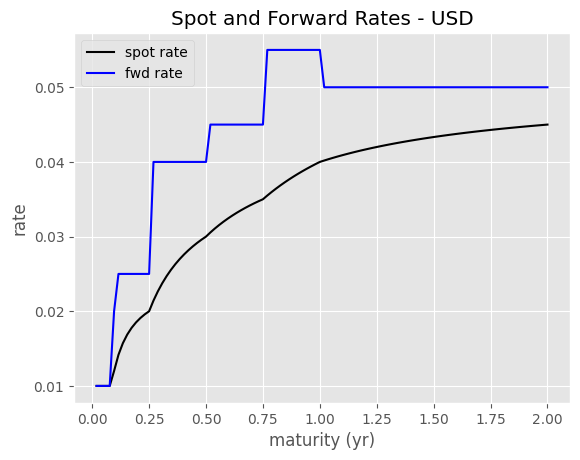

In [8]:
# plot
plt.plot(tweekly, spotRates, color='black', label="spot rate")
plt.plot(tweekly, fwdRates, color='blue', label="fwd rate")
plt.title("Spot and Forward Rates - USD")
plt.legend(loc="upper left")
plt.xlabel('maturity (yr)')
plt.ylabel('rate');

In [9]:
# list market contents
print(orf.mktList())

{'YieldCurves': ['USD'], 'Volatilities': []}


In [10]:
#yccreate2
ycname = "USD-LIBOR"
yc2 = orf.ycCreate(ycname = ycname, 
                  tmats = [1/12,   1/4,  1/2,   3/4,    1,     2,    3,    5], 
                  vals =  [0.01,  0.02, 0.03, 0.035, 0.04, 0.0475, 0.0525, 0.06],
                  valtype = 0)
print(f'Created yield curve: {yc}')

Created yield curve: USD


In [11]:
#create a 2 year weekly array
tweekly = [i / 12.0 for i in range(1, 37)]
spotRates = [orf.spotRate(yc2, tmat) for tmat in tweekly] 
fwdRates = [orf.fwdRate(yc2, tmat1, tmat2 ) for tmat1, tmat2 in zip(tweekly[:-1], tweekly[1:])]
fwdRates.insert(0, orf.fwdRate(yc, 0, tweekly[0]))

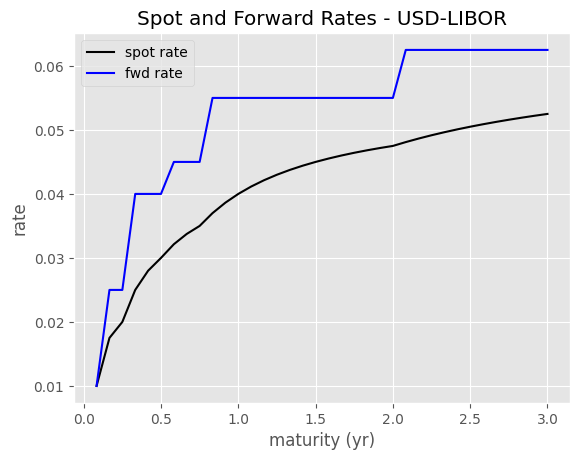

In [12]:
# plot
plt.plot(tweekly, spotRates, color='black', label="spot rate")
plt.plot(tweekly, fwdRates, color='blue', label="fwd rate")
plt.title("Spot and Forward Rates - USD-LIBOR")
plt.legend(loc="upper left")
plt.xlabel('maturity (yr)')
plt.ylabel('rate');

In [13]:
manual_calculations = []
durs = [1/12,   1/4,  1/2,   3/4,    1,     2,    3,    5]
ints =  [0.01,  0.02, 0.03, 0.035, 0.04, 0.0475, 0.0525, 0.06]
for i in range(1,37,1):
    mon=float(i)/12
    for j in range(len(durs)):
        if durs[j]>=mon:
            if j==0:
                manual_calculations.append(ints[j])
                break
            else:
                intf = ((ints[j]*durs[j])-(ints[j-1]*durs[j-1]))/(durs[j]-durs[j-1])
                manual_calculations.append(intf)
                break
                                                                                                                                 

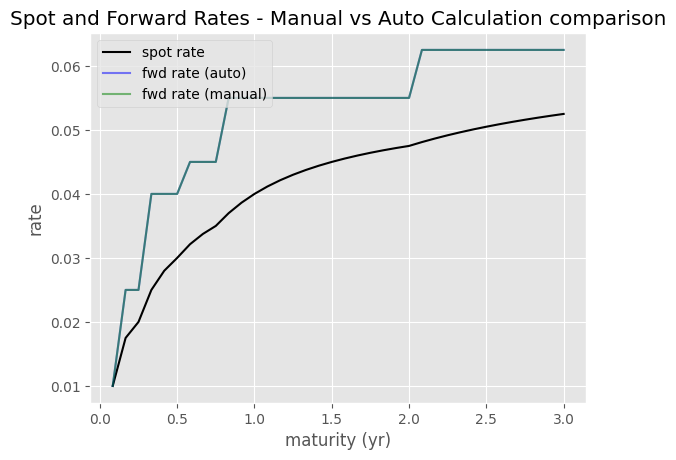

In [14]:
# plot
plt.plot(tweekly, spotRates, color='black', label="spot rate")
plt.plot(tweekly, fwdRates, color='blue', alpha =0.5, label="fwd rate (auto)")
plt.plot(tweekly, manual_calculations, color='green', alpha=0.5, label="fwd rate (manual)")
plt.title("Spot and Forward Rates - Manual vs Auto Calculation comparison")
plt.legend(loc="upper left")
plt.xlabel('maturity (yr)')
plt.ylabel('rate');

We see here that the lines perfectly overlap and thus the manual and auto calculations are exactly the same.

In [15]:
#volcreate
volname = "VOLTS"
vc = orf.volCreate(volname = volname, 
                  tmats = [1/4,   1/2,  3/4,   1,   1.5,    2,   3,    4], 
                  vols =  [0.20,  0.22, 0.23, 0.25, 0.27, 0.30, 0.35, 0.40],
                  voltype = 0)
print(f'Created volatility curve: {vc}')

Created volatility curve: VOLTS


In [16]:
tmats = [1/4,   1/2,  3/4,   1,   1.5,    2,   3,    4]
spotVols = [orf.spotVol(vc, tmat) for tmat in tmats] 
fwdVols = [orf.fwdVol(vc, tmat1, tmat2 ) for tmat1, tmat2 in zip(tmats[:-1], tmats[1:])]
fwdVols.insert(0, orf.fwdVol(vc, 0, tmats[0]))

In [17]:
manual_calculations = []
tmats = [1/4,   1/2,  3/4,   1,   1.5,    2,   3,    4]
vols =  [0.20,  0.22, 0.23, 0.25, 0.27, 0.30, 0.35, 0.40]
for i in range(len(tmats)):
    mon=tmats[i]
    for j in range(len(tmats)):
        if tmats[j]>=mon:
            if j==0:
                manual_calculations.append(vols[j])
                break
            else:
                volf = (((vols[j]**2)*tmats[j])-((vols[j-1]**2)*tmats[j-1]))/(tmats[j]-tmats[j-1])
                volf = float(np.sqrt(volf))
                manual_calculations.append(volf)
                break
                          

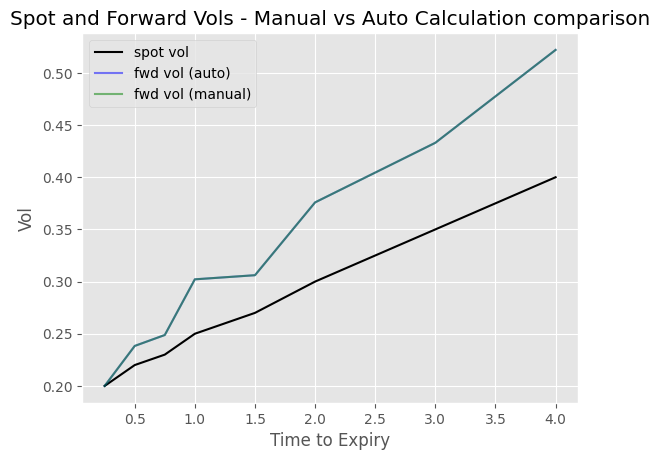

In [18]:
# plot
plt.plot(tmats, spotVols, color='black', label="spot vol")
plt.plot(tmats, fwdVols, color='blue', alpha =0.5, label="fwd vol (auto)")
plt.plot(tmats, manual_calculations, color='green', alpha=0.5, label="fwd vol (manual)")
plt.title("Spot and Forward Vols - Manual vs Auto Calculation comparison")
plt.legend(loc="upper left")
plt.xlabel('Time to Expiry')
plt.ylabel('Vol');

We see here that the lines perfectly overlap and thus the manual and auto calculations are exactly the same.